# VAR-Modell: Bitcoin · DAX · Gold (2016–2026)
> **Projekt:** Asset Forecasting — DAX, Gold & Bitcoin  
> **Kurs:** Vertiefung Business Analytics · THWS · SoSe 2026  
> **Prof.:** Dr. Christian Menden  
> **Autor:** Nico Hirsch  
> **Methode:** Vector Autoregression (VAR) — alle drei Assets gemeinsam

---

## Methodik — VAR (Vector Autoregression)

Ein **VAR(p)-Modell** modelliert mehrere Zeitreihen simultan. Jede Variable wird durch ihre eigenen Verzögerungen **und** die Verzögerungen aller anderen Variablen erklärt:

$$y_t = c + A_1 y_{t-1} + A_2 y_{t-2} + \cdots + A_p y_{t-p} + \varepsilon_t$$

**Voraussetzung:** Alle Variablen müssen **stationär** sein → Transformation in Log-Returns.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import logging
logging.captureWarnings(True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Plot-Stil (identisch zu den anderen Notebooks)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

COLORS = {'Bitcoin': '#F7931A', 'DAX': '#1f77b4', 'Gold': '#FFD700'}

print('Setup abgeschlossen ✓')

Setup abgeschlossen ✓


---
## 1. Daten laden & aufbereiten

In [2]:
# Hilfsfunktion: CSV einlesen (skiprows=1 wegen Ticker-Zeile)
def load_series(filename: str, col_name: str) -> pd.Series:
    path = os.path.join('..', 'data', 'raw', filename)
    df   = pd.read_csv(path, skiprows=1, header=0)
    df.columns = ['Date', col_name]
    df   = df.dropna(subset=['Date', col_name])
    df['Date'] = pd.to_datetime(df['Date'])
    df   = df.set_index('Date').sort_index()
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
    return df[col_name].dropna()

btc  = load_series('bitcoin_kurs_2016_2026.csv', 'Bitcoin')
dax  = load_series('dax_kurs_2016_2026.csv',     'DAX')
gold = load_series('goldpreis_2016_2026.csv',     'Gold')

# Gemeinsamer Datumsschnitt (nur Tage, an denen alle drei Werte vorliegen)
df_raw = pd.concat([btc, dax, gold], axis=1).dropna()
df_raw.index.freq = None

print(f'Zeitraum      : {df_raw.index[0].date()} → {df_raw.index[-1].date()}')
print(f'Beobachtungen : {len(df_raw)}')
print()
print(df_raw.head())

Zeitraum      : 2016-01-04 → 2026-05-01
Beobachtungen : 2594

               Bitcoin        DAX         Gold
Date                                          
2016-01-04  433.091003  18.942085  1075.099976
2016-01-05  431.959991  18.831541  1078.400024
2016-01-06  429.105011  18.618353  1091.900024
2016-01-07  458.048004  18.286734  1107.699951
2016-01-08  453.230011  18.113026  1097.800049


In [3]:
# Log-Returns berechnen (VAR benötigt stationäre Reihen)
df_ret = np.log(df_raw).diff().dropna()
df_ret.columns = ['Bitcoin_ret', 'DAX_ret', 'Gold_ret']

print('Deskriptive Statistik der Log-Returns:')
print(df_ret.describe().round(6))

Deskriptive Statistik der Log-Returns:
       Bitcoin_ret      DAX_ret     Gold_ret
count  2593.000000  2593.000000  2593.000000
mean      0.002004     0.000335     0.000563
std       0.042003     0.013450     0.010435
min      -0.464730    -0.120154    -0.120657
25%      -0.015386    -0.005901    -0.004171
50%       0.001772     0.000634     0.000669
75%       0.020249     0.007257     0.005932
max       0.225119     0.092149     0.059054


---
## 2. Stationaritätsprüfung (ADF-Test)

In [4]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    crit = result[4]
    stationaer = pval <= 0.05
    print(f'ADF-Test: {name}')
    print(f'  Teststatistik : {stat:.4f}')
    print(f'  p-Wert        : {pval:.4f}  → {"✅ Stationär" if stationaer else "❌ Nicht stationär"} (α=5%)')
    print(f'  Kritische Werte: 1%={crit["1%"]:.3f}, 5%={crit["5%"]:.3f}')
    print()

print('='*55)
print('NIVEAUPREISE')
print('='*55)
for col in df_raw.columns:
    adf_test(df_raw[col], col)

print('='*55)
print('LOG-RETURNS')
print('='*55)
for col in df_ret.columns:
    adf_test(df_ret[col], col)

print('→ Fazit: Niveaupreise sind I(1) → Log-Returns I(0) → geeignet für VAR.')

NIVEAUPREISE
ADF-Test: Bitcoin
  Teststatistik : -1.0728
  p-Wert        : 0.7258  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

ADF-Test: DAX
  Teststatistik : -0.1575
  p-Wert        : 0.9434  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

ADF-Test: Gold
  Teststatistik : 2.4004
  p-Wert        : 0.9990  → ❌ Nicht stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

LOG-RETURNS
ADF-Test: Bitcoin_ret
  Teststatistik : -27.8971
  p-Wert        : 0.0000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

ADF-Test: DAX_ret
  Teststatistik : -16.7627
  p-Wert        : 0.0000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

ADF-Test: Gold_ret
  Teststatistik : -20.9623
  p-Wert        : 0.0000  → ✅ Stationär (α=5%)
  Kritische Werte: 1%=-3.433, 5%=-2.863

→ Fazit: Niveaupreise sind I(1) → Log-Returns I(0) → geeignet für VAR.


---
## 3. Explorative Analyse (EDA)

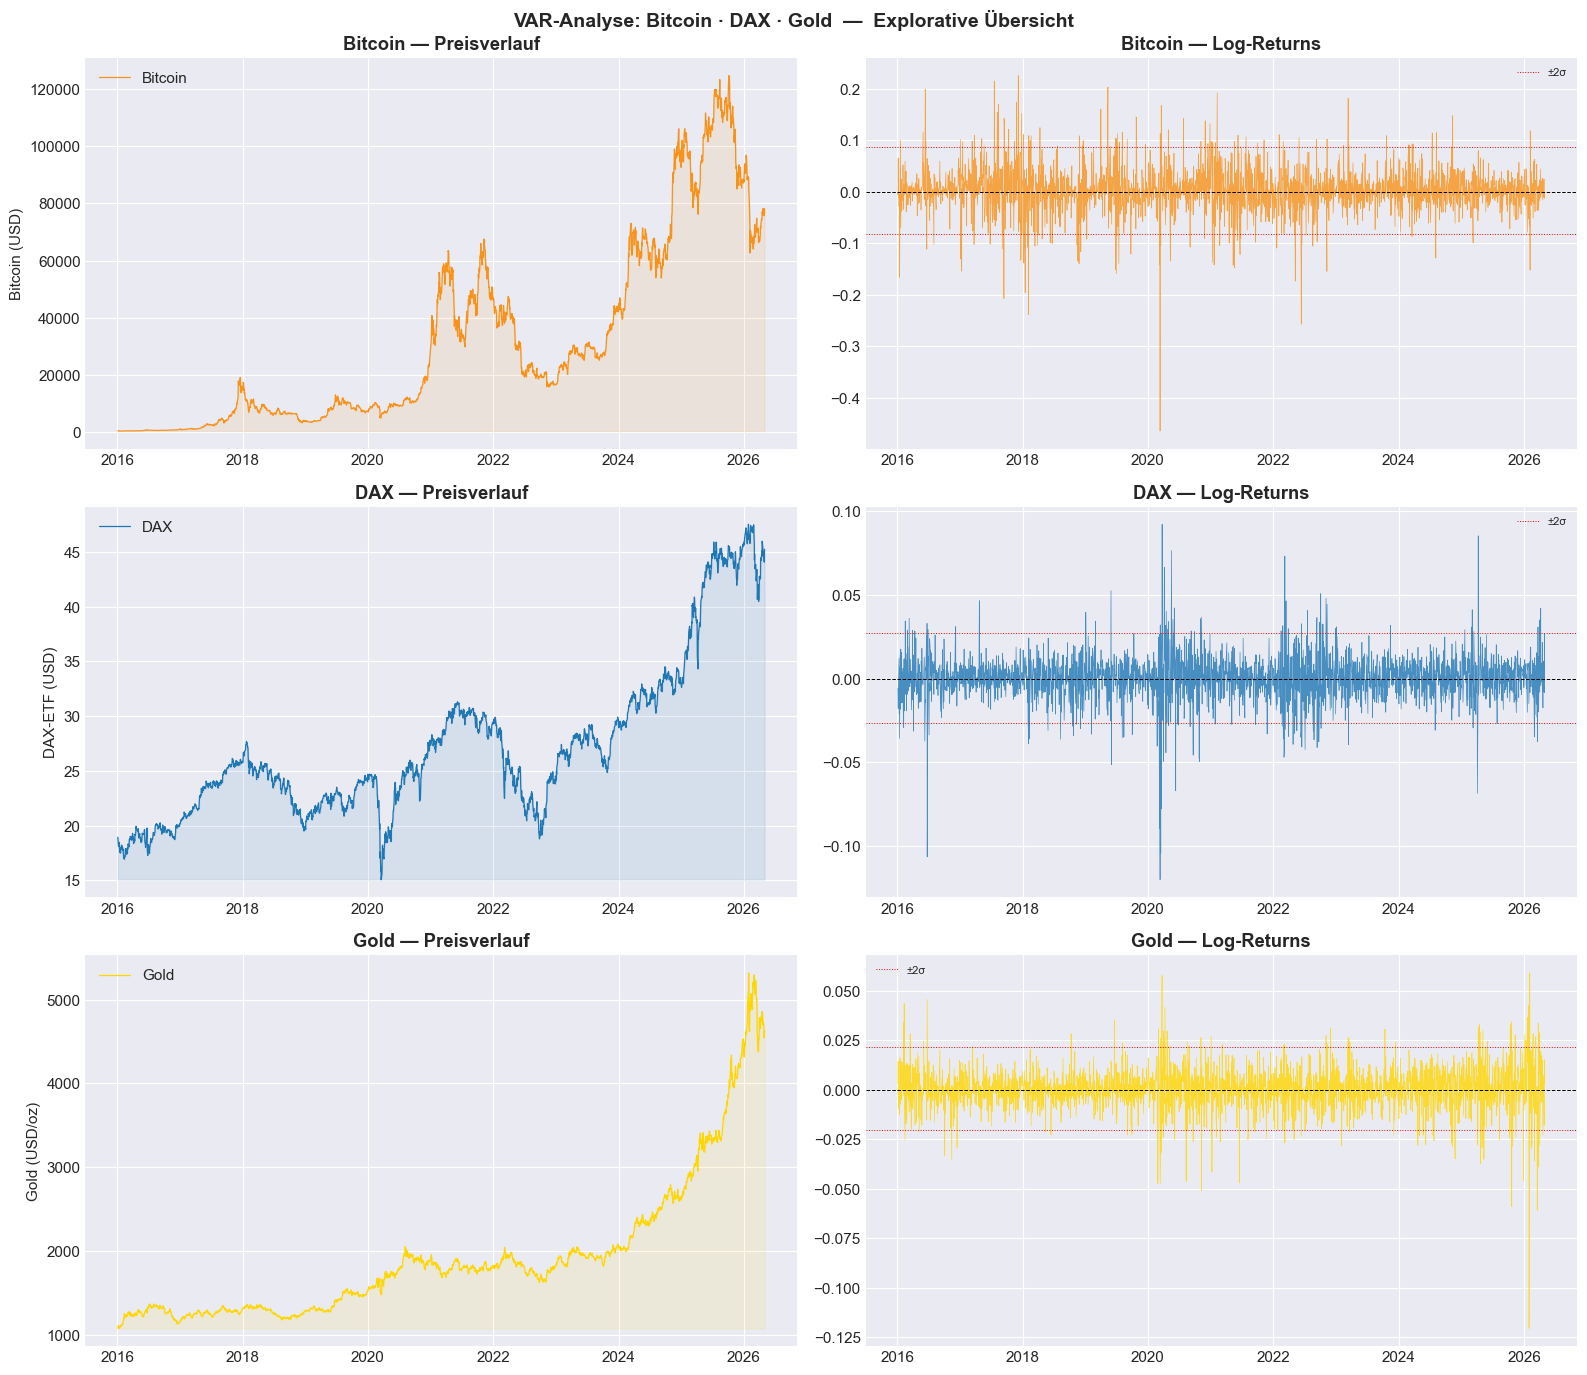

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('VAR-Analyse: Bitcoin · DAX · Gold  —  Explorative Übersicht',
             fontsize=14, fontweight='bold')

assets = [('Bitcoin', 'Bitcoin_ret', 'Bitcoin (USD)'),
          ('DAX',     'DAX_ret',     'DAX-ETF (USD)'),
          ('Gold',    'Gold_ret',    'Gold (USD/oz)')]

for i, (asset, ret_col, ylabel) in enumerate(assets):
    color = COLORS[asset]
    # Preisverlauf
    axes[i, 0].plot(df_raw.index, df_raw[asset], color=color, linewidth=0.9, label=asset)
    axes[i, 0].fill_between(df_raw.index, df_raw[asset], df_raw[asset].min(),
                             alpha=0.1, color=color)
    axes[i, 0].set_title(f'{asset} — Preisverlauf', fontweight='bold')
    axes[i, 0].set_ylabel(ylabel)
    axes[i, 0].legend()
    # Log-Returns
    axes[i, 1].plot(df_ret.index, df_ret[ret_col], color=color, linewidth=0.5, alpha=0.8)
    axes[i, 1].axhline(0, color='black', linewidth=0.7, linestyle='--')
    axes[i, 1].axhline(df_ret[ret_col].mean() + 2*df_ret[ret_col].std(),
                       color='red', linewidth=0.7, linestyle=':', label='±2σ')
    axes[i, 1].axhline(df_ret[ret_col].mean() - 2*df_ret[ret_col].std(),
                       color='red', linewidth=0.7, linestyle=':')
    axes[i, 1].set_title(f'{asset} — Log-Returns', fontweight='bold')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/var_eda.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Korrelationsanalyse der Log-Returns

Korrelationsmatrix der Log-Returns:
         Bitcoin     DAX    Gold
Bitcoin   1.0000  0.2323  0.0905
DAX       0.2323  1.0000  0.1087
Gold      0.0905  0.1087  1.0000


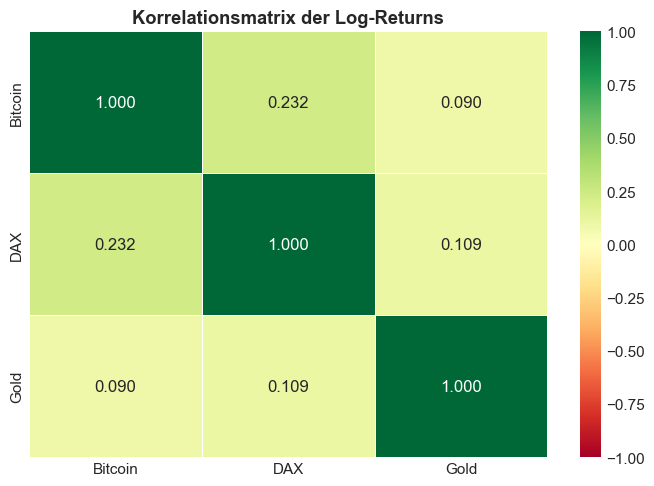

In [6]:
corr = df_ret.corr()
corr.index   = ['Bitcoin', 'DAX', 'Gold']
corr.columns = ['Bitcoin', 'DAX', 'Gold']

print('Korrelationsmatrix der Log-Returns:')
print(corr.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_title('Korrelationsmatrix der Log-Returns', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/var_korrelation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Granger-Kausalitätstests

In [7]:
col_labels = {'Bitcoin_ret': 'Bitcoin', 'DAX_ret': 'DAX', 'Gold_ret': 'Gold'}
pairs = [
    ('Bitcoin_ret', 'DAX_ret'),
    ('Bitcoin_ret', 'Gold_ret'),
    ('DAX_ret',     'Bitcoin_ret'),
    ('DAX_ret',     'Gold_ret'),
    ('Gold_ret',    'Bitcoin_ret'),
    ('Gold_ret',    'DAX_ret'),
]

print(f'  {"Ursache → Wirkung":<30}  p-Wert   Ergebnis')
print('  ' + '-' * 55)
for cause, effect in pairs:
    gc_data = df_ret[[effect, cause]].dropna()
    gc_res  = grangercausalitytests(gc_data, maxlag=5, verbose=False)
    p = gc_res[1][0]['ssr_ftest'][1]
    label  = f'{col_labels[cause]} → {col_labels[effect]}'
    result = '✅ Granger-kausal' if p < 0.05 else '  kein Effekt'
    print(f'  {label:<30}  p={p:.4f}  {result}')

  Ursache → Wirkung               p-Wert   Ergebnis
  -------------------------------------------------------
  Bitcoin → DAX                   p=0.8447    kein Effekt
  Bitcoin → Gold                  p=0.2622    kein Effekt
  DAX → Bitcoin                   p=0.1946    kein Effekt
  DAX → Gold                      p=0.0003  ✅ Granger-kausal
  Gold → Bitcoin                  p=0.8569    kein Effekt
  Gold → DAX                      p=0.0167  ✅ Granger-kausal


---
## 6. Modellidentifikation & Schätzung

### 6.1 Lag-Selektion (AIC/BIC/HQIC/FPE)

In [8]:
# Train-Test-Split (letzte 60 Handelstage als Test)
TEST_SIZE = 60
train_ret = df_ret.iloc[:-TEST_SIZE]
test_ret  = df_ret.iloc[-TEST_SIZE:]

print(f'Training: {train_ret.index[0].date()} → {train_ret.index[-1].date()} ({len(train_ret)} Tage)')
print(f'Test    : {test_ret.index[0].date()}  → {test_ret.index[-1].date()}  ({len(test_ret)} Tage)')

var_selector = VAR(train_ret)
lag_results  = var_selector.select_order(maxlags=15)
print()
print(lag_results.summary())

best_lag = int(lag_results.aic)
best_lag = max(1, min(best_lag, 10))
print(f'\n→ Gewählter Lag (AIC): {best_lag}')

Training: 2016-01-05 → 2026-02-04 (2533 Tage)
Test    : 2026-02-05  → 2026-05-01  (60 Tage)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -24.22     -24.21*   3.035e-11     -24.22*
1       -24.22      -24.19   3.028e-11      -24.21
2       -24.23      -24.18   3.009e-11      -24.21
3       -24.22      -24.15   3.017e-11      -24.20
4       -24.22      -24.13   3.024e-11      -24.19
5       -24.22      -24.11   3.035e-11      -24.18
6       -24.23      -24.09   3.013e-11      -24.18
7      -24.23*      -24.08  2.999e-11*      -24.17
8       -24.23      -24.05   3.013e-11      -24.16
9       -24.22      -24.03   3.022e-11      -24.15
10      -24.22      -24.00   3.029e-11      -24.14
11      -24.22      -23.98   3.041e-11      -24.13
12      -24.21      -23.96   3.046e-11      -24.12
13      -24.21      -23.93   3.061e-11      -24.11
14      -24.21      -23.91   3.066e-11  

### 6.2 VAR-Modell schätzen

In [9]:
var_model  = VAR(train_ret)
var_fitted = var_model.fit(maxlags=best_lag, ic=None, trend='c')

print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 18, May, 2026
Time:                     09:46:26
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.0685
Nobs:                     2526.00    HQIC:                  -24.1657
Log likelihood:           19904.4    FPE:                3.02667e-11
AIC:                     -24.2210    Det(Omega_mle):     2.94894e-11
--------------------------------------------------------------------
Results for equation Bitcoin_ret
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.002091         0.000854            2.447           0.014
L1.Bitcoin_ret        -0.013164         0.020552           -0.641           0.522
L1.DAX_ret            -0.082405         0.065217  

---
## 7. Residualdiagnostik

In [10]:
residuals_df = var_fitted.resid.copy()
residuals_df.columns = ['Bitcoin_res', 'DAX_res', 'Gold_res']
residuals_df = residuals_df.dropna()

# Durbin-Watson
dw_stats = durbin_watson(residuals_df.values)
for col, dw in zip(['Bitcoin', 'DAX', 'Gold'], dw_stats):
    flag = '✅ ok' if 1.5 < dw < 2.5 else '⚠️  prüfen'
    print(f'Durbin-Watson {col:<10}: {dw:.4f}  {flag}')

print()

# Ljung-Box
for col in residuals_df.columns:
    series = residuals_df[col].dropna().values
    lb = acorr_ljungbox(series, lags=[10], return_df=True)
    p  = lb['lb_pvalue'].values[0]
    flag  = '✅ Weißes Rauschen' if p > 0.05 else '⚠️  Autokorrelation'
    asset = col.replace('_res', '')
    print(f'Ljung-Box (Lag 10) {asset:<10}: p={p:.4f}  → {flag}')

Durbin-Watson Bitcoin   : 1.9984  ✅ ok
Durbin-Watson DAX       : 1.9955  ✅ ok
Durbin-Watson Gold      : 1.9972  ✅ ok

Ljung-Box (Lag 10) Bitcoin   : p=0.9929  → ✅ Weißes Rauschen
Ljung-Box (Lag 10) DAX       : p=0.7814  → ✅ Weißes Rauschen
Ljung-Box (Lag 10) Gold      : p=1.0000  → ✅ Weißes Rauschen


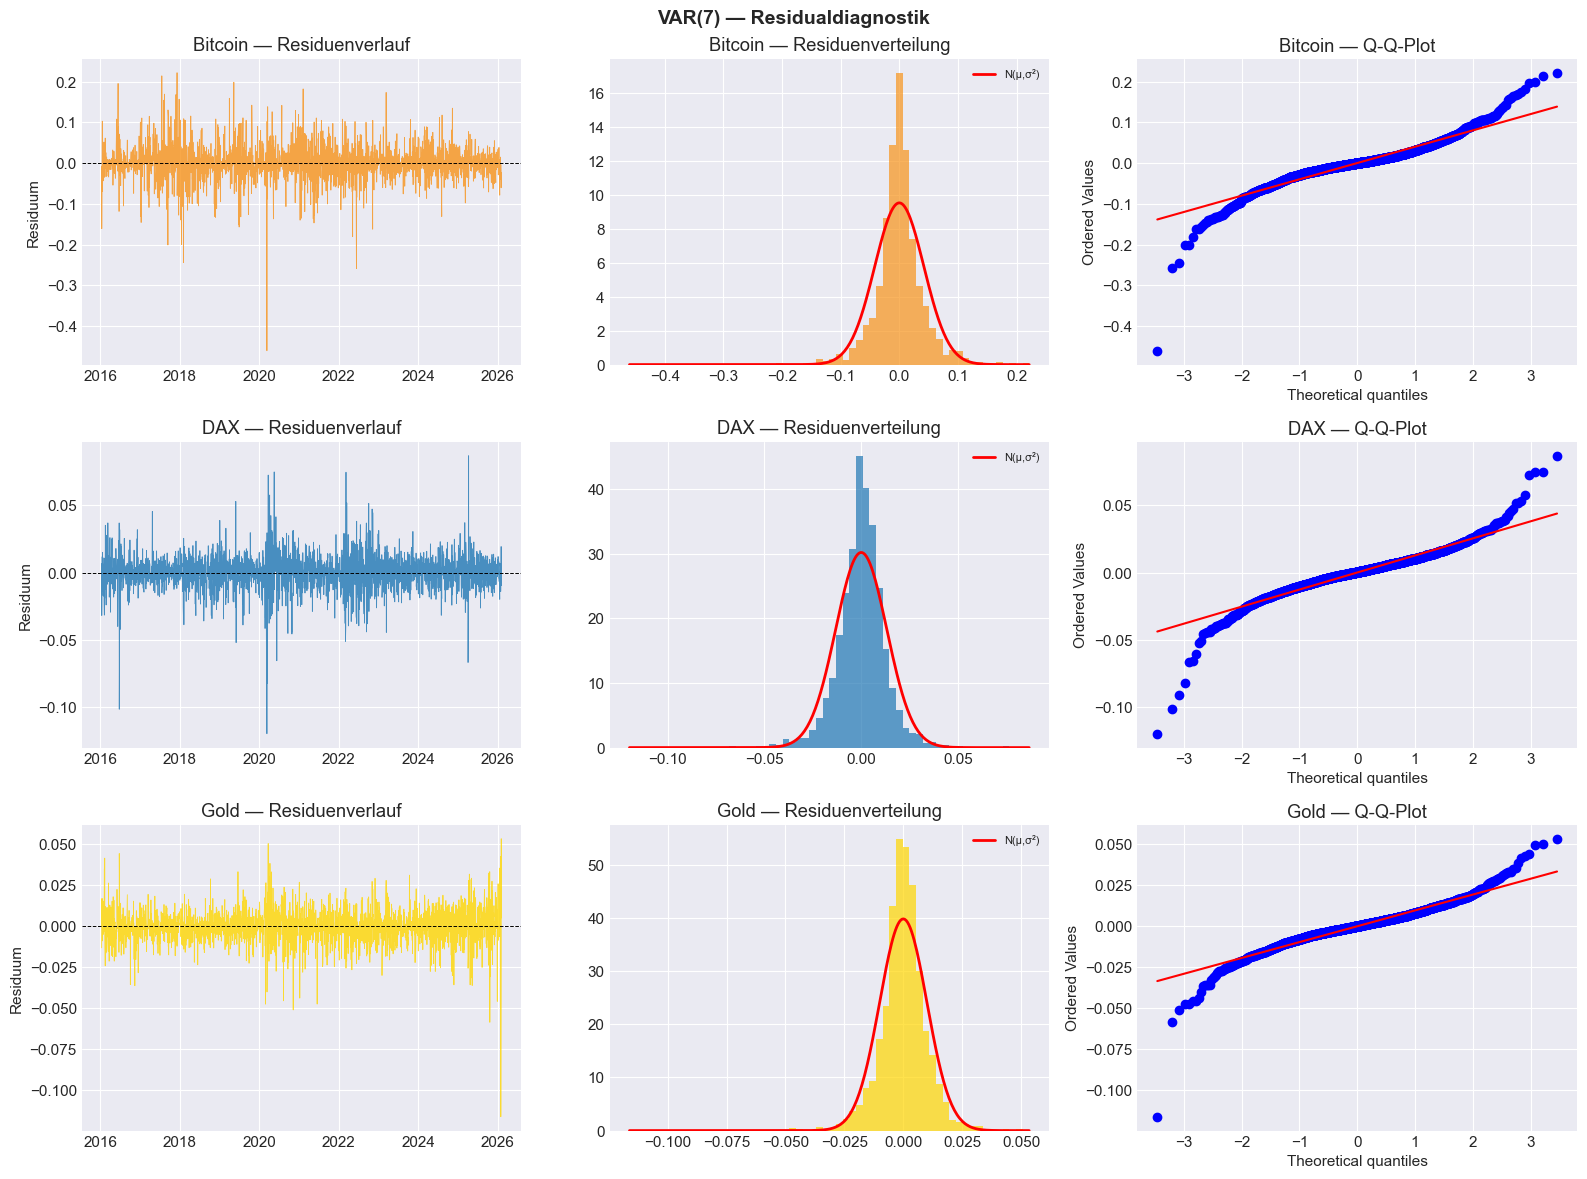

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle(f'VAR({best_lag}) — Residualdiagnostik', fontsize=14, fontweight='bold')

res_labels = [('Bitcoin_res', 'Bitcoin'), ('DAX_res', 'DAX'), ('Gold_res', 'Gold')]
for i, (col, label) in enumerate(res_labels):
    color = list(COLORS.values())[i]
    res   = residuals_df[col]

    axes[i, 0].plot(res.index, res, color=color, linewidth=0.6, alpha=0.8)
    axes[i, 0].axhline(0, color='black', linewidth=0.7, linestyle='--')
    axes[i, 0].set_title(f'{label} — Residuenverlauf')
    axes[i, 0].set_ylabel('Residuum')

    axes[i, 1].hist(res, bins=60, density=True, color=color, alpha=0.7, edgecolor='none')
    x = np.linspace(res.min(), res.max(), 300)
    axes[i, 1].plot(x, stats.norm.pdf(x, res.mean(), res.std()),
                    color='red', linewidth=2, label='N(μ,σ²)')
    axes[i, 1].set_title(f'{label} — Residuenverteilung')
    axes[i, 1].legend(fontsize=8)

    stats.probplot(res, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{label} — Q-Q-Plot')

plt.tight_layout()
plt.savefig('../reports/var_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Backtesting (60 Handelstage Out-of-Sample)

In [12]:
lag_input = train_ret.values[-best_lag:]
fc_obj    = var_fitted.forecast(y=lag_input, steps=TEST_SIZE)
fc_ret_df = pd.DataFrame(fc_obj, index=test_ret.index,
                          columns=['Bitcoin_ret', 'DAX_ret', 'Gold_ret'])

# Preisprognose aus Log-Returns rekonstruieren
last_prices  = df_raw.iloc[-(TEST_SIZE + 1)].values
fc_prices    = last_prices * np.exp(fc_ret_df.values.cumsum(axis=0))
fc_prices_df = pd.DataFrame(fc_prices, index=test_ret.index,
                              columns=['Bitcoin', 'DAX', 'Gold'])
test_prices  = df_raw.iloc[-TEST_SIZE:]

# Metriken
metrics = {}
print(f'  {"Asset":<10}  {"MAE":>14}  {"RMSE":>14}  {"MAPE":>8}')
print('  ' + '-' * 55)
for col in ['Bitcoin', 'DAX', 'Gold']:
    actual    = test_prices[col].values
    predicted = fc_prices_df[col].values
    mae  = np.mean(np.abs(predicted - actual))
    rmse = np.sqrt(np.mean((predicted - actual)**2))
    mape = np.mean(np.abs((predicted - actual) / actual)) * 100
    metrics[col] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
    print(f'  {col:<10}  {mae:>14,.2f}  {rmse:>14,.2f}  {mape:>7.3f}%')

  Asset                  MAE            RMSE      MAPE
  -------------------------------------------------------
  Bitcoin           8,175.51        8,528.21   11.710%
  DAX                   2.68            3.20    6.207%
  Gold                267.82          320.57    5.676%


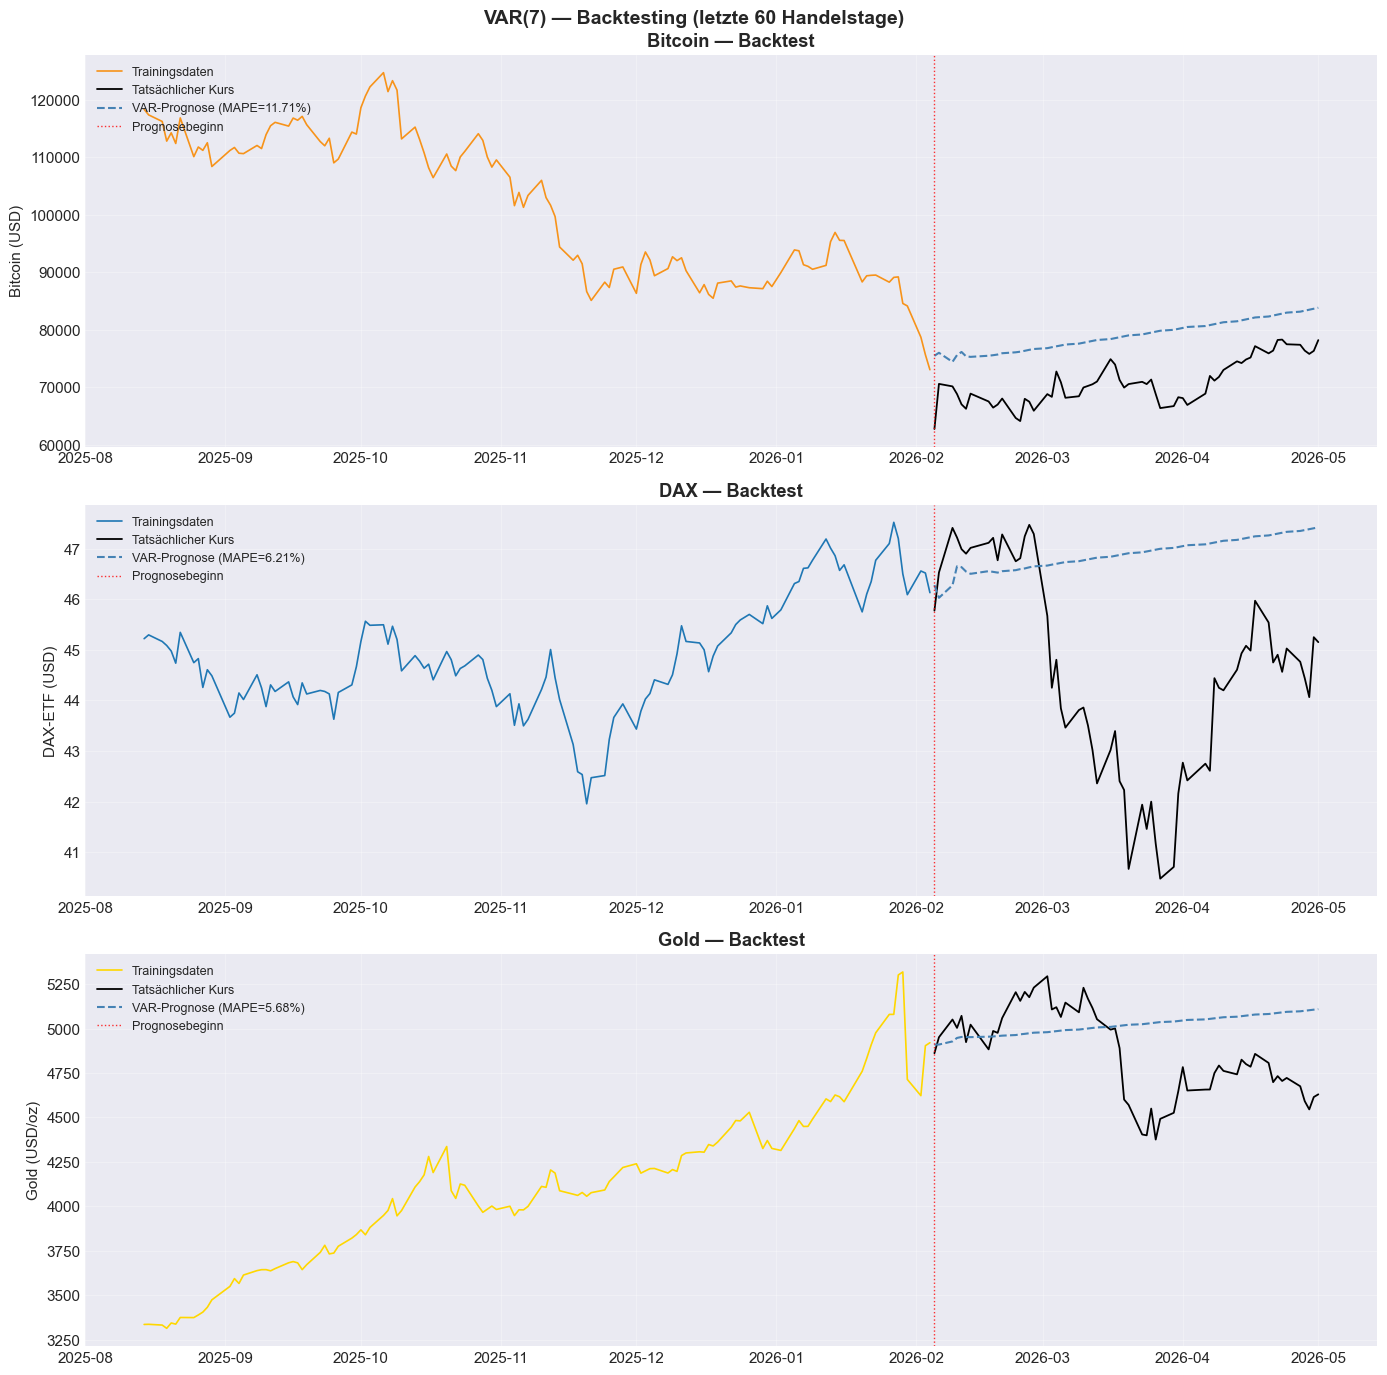

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'VAR({best_lag}) — Backtesting (letzte 60 Handelstage)',
             fontsize=14, fontweight='bold')

for i, (col, ylabel) in enumerate([('Bitcoin', 'Bitcoin (USD)'),
                                    ('DAX',     'DAX-ETF (USD)'),
                                    ('Gold',    'Gold (USD/oz)')]):
    color     = COLORS[col]
    show_from = df_raw.index[-180]

    axes[i].plot(df_raw.loc[show_from:df_raw.index[-(TEST_SIZE + 1)]].index,
                 df_raw.loc[show_from:df_raw.index[-(TEST_SIZE + 1)], col],
                 color=color, linewidth=1.2, label='Trainingsdaten')
    axes[i].plot(test_prices.index, test_prices[col],
                 color='black', linewidth=1.3, label='Tatsächlicher Kurs')
    axes[i].plot(fc_prices_df.index, fc_prices_df[col],
                 color='steelblue', linewidth=1.5, linestyle='--',
                 label=f'VAR-Prognose (MAPE={metrics[col]["MAPE"]:.2f}%)')
    axes[i].axvline(test_prices.index[0], color='red', linewidth=1,
                    linestyle=':', alpha=0.8, label='Prognosebeginn')
    axes[i].set_title(f'{col} — Backtest', fontweight='bold')
    axes[i].set_ylabel(ylabel)
    axes[i].legend(fontsize=9, loc='upper left')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/var_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Prognose (10 Handelstage)

In [14]:
# Finales Modell auf Gesamtdaten
var_final        = VAR(df_ret)
var_final_fitted = var_final.fit(maxlags=best_lag, ic=None, trend='c')

lag_input_final = df_ret.values[-best_lag:]
fc10_ret        = var_final_fitted.forecast(y=lag_input_final, steps=10)
fc10_ret_df     = pd.DataFrame(fc10_ret, columns=['Bitcoin_ret', 'DAX_ret', 'Gold_ret'])

last_known  = df_raw.iloc[-1].values
fc10_prices = last_known * np.exp(fc10_ret_df.values.cumsum(axis=0))
fc10_dates  = pd.bdate_range(df_raw.index[-1] + pd.Timedelta(days=1), periods=10)
fc10_df     = pd.DataFrame(fc10_prices, index=fc10_dates,
                             columns=['Bitcoin', 'DAX', 'Gold'])

print(f'10-Tage-Prognose — VAR({best_lag}):')
print()
print(f'  {"Tag":<4} {"Datum":<12}  {"Bitcoin (USD)":>15}  {"DAX (USD)":>12}  {"Gold (USD/oz)":>15}')
print('  ' + '='*65)
for i, (date, row) in enumerate(fc10_df.iterrows(), 1):
    print(f'  {i:<4} {date.strftime("%Y-%m-%d"):<12}  '
          f'{row["Bitcoin"]:>15,.2f}  {row["DAX"]:>12,.4f}  {row["Gold"]:>15,.2f}')

print()
print(f'  Letzter bekannter Preis:')
print(f'    Bitcoin : ${df_raw["Bitcoin"].iloc[-1]:,.2f}')
print(f'    DAX     : ${df_raw["DAX"].iloc[-1]:,.4f}')
print(f'    Gold    : ${df_raw["Gold"].iloc[-1]:,.2f}')

10-Tage-Prognose — VAR(7):

  Tag  Datum           Bitcoin (USD)     DAX (USD)    Gold (USD/oz)
  1    2026-05-04          78,786.89       45.2208         4,631.82
  2    2026-05-05          79,203.56       45.2605         4,634.50
  3    2026-05-06          79,538.20       45.3434         4,644.61
  4    2026-05-07          79,516.40       45.4931         4,653.82
  5    2026-05-08          79,839.04       45.3922         4,650.79
  6    2026-05-11          80,034.56       45.4506         4,654.40
  7    2026-05-12          80,187.34       45.4408         4,654.34
  8    2026-05-13          80,365.45       45.4659         4,657.23
  9    2026-05-14          80,531.37       45.4777         4,658.87
  10   2026-05-15          80,738.65       45.4776         4,660.83

  Letzter bekannter Preis:
    Bitcoin : $78,179.00
    DAX     : $45.1520
    Gold    : $4,629.90


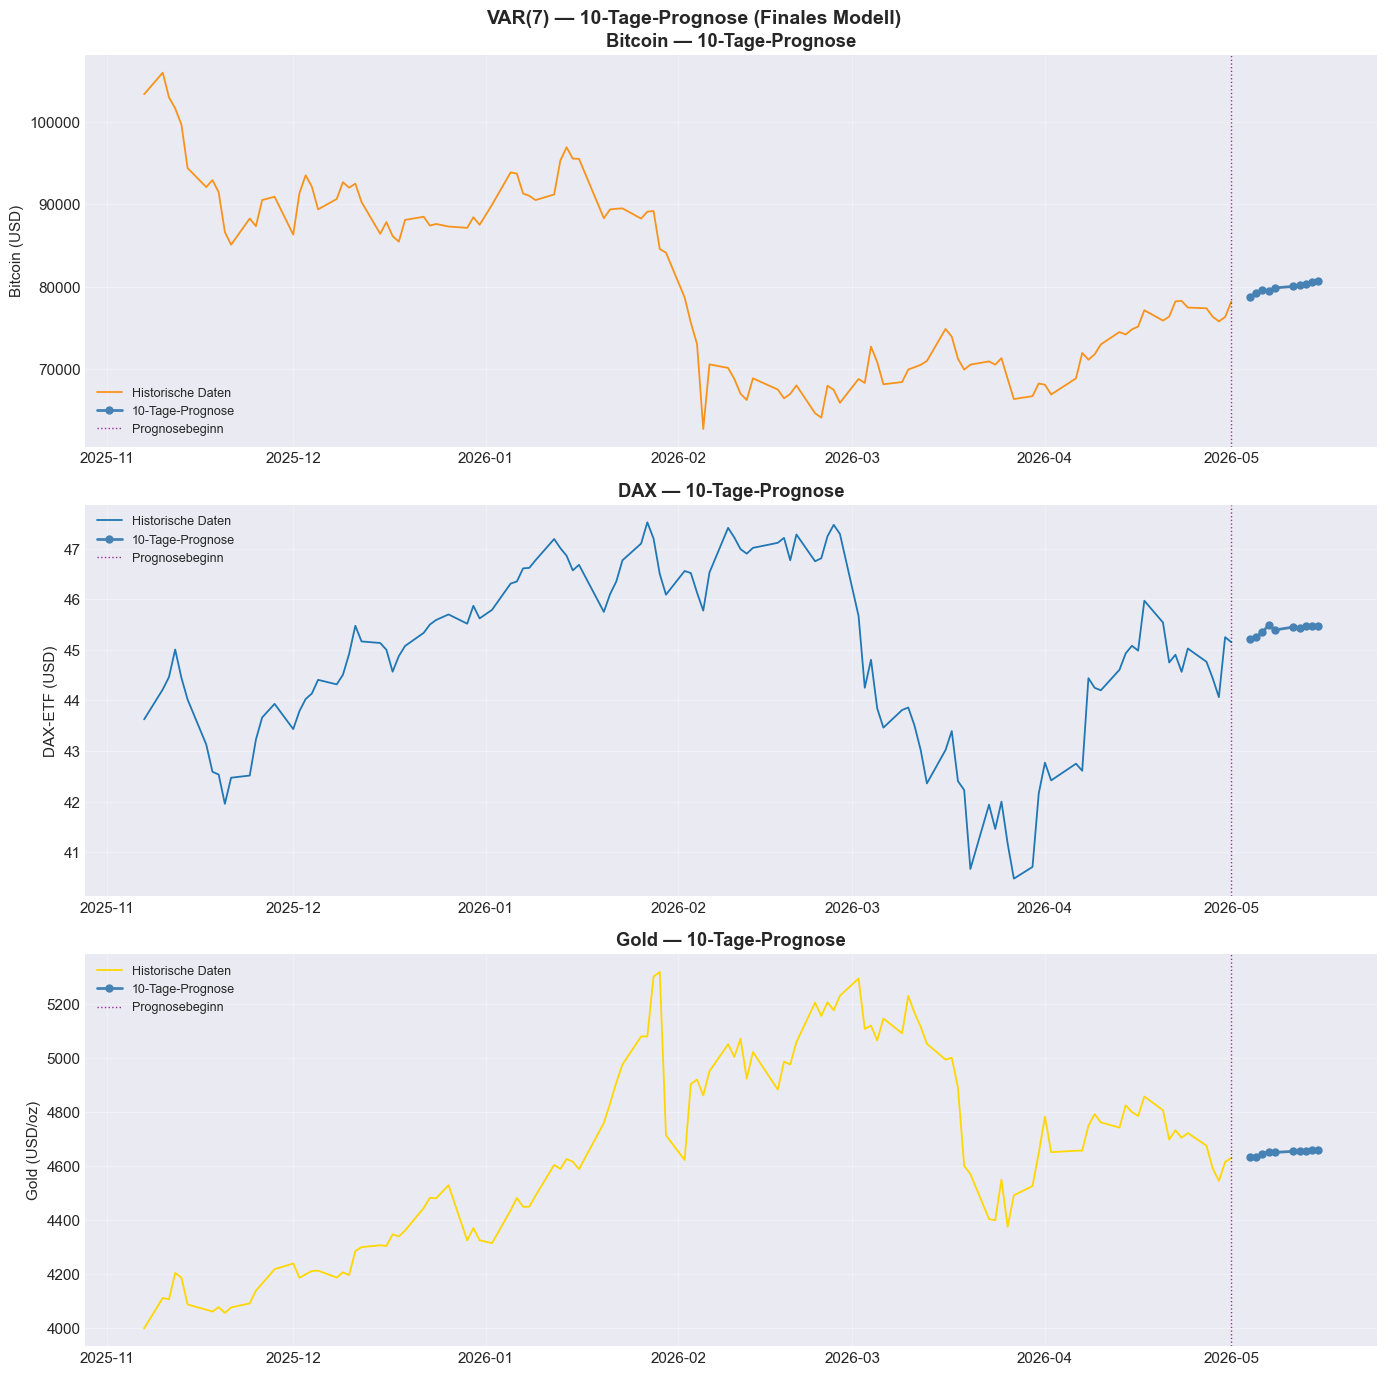

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'VAR({best_lag}) — 10-Tage-Prognose (Finales Modell)',
             fontsize=14, fontweight='bold')

for i, (col, ylabel) in enumerate([('Bitcoin', 'Bitcoin (USD)'),
                                    ('DAX',     'DAX-ETF (USD)'),
                                    ('Gold',    'Gold (USD/oz)')]):
    color     = COLORS[col]
    show_from = df_raw.index[-120]

    axes[i].plot(df_raw.loc[show_from:].index, df_raw.loc[show_from:, col],
                 color=color, linewidth=1.3, label='Historische Daten')
    axes[i].plot(fc10_df.index, fc10_df[col],
                 color='steelblue', linewidth=2.0,
                 marker='o', markersize=5, label='10-Tage-Prognose')
    axes[i].axvline(df_raw.index[-1], color='purple', linewidth=1,
                    linestyle=':', alpha=0.8, label='Prognosebeginn')
    axes[i].set_title(f'{col} — 10-Tage-Prognose', fontweight='bold')
    axes[i].set_ylabel(ylabel)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/var_forecast_10d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Impuls-Antwort-Funktionen (IRF)

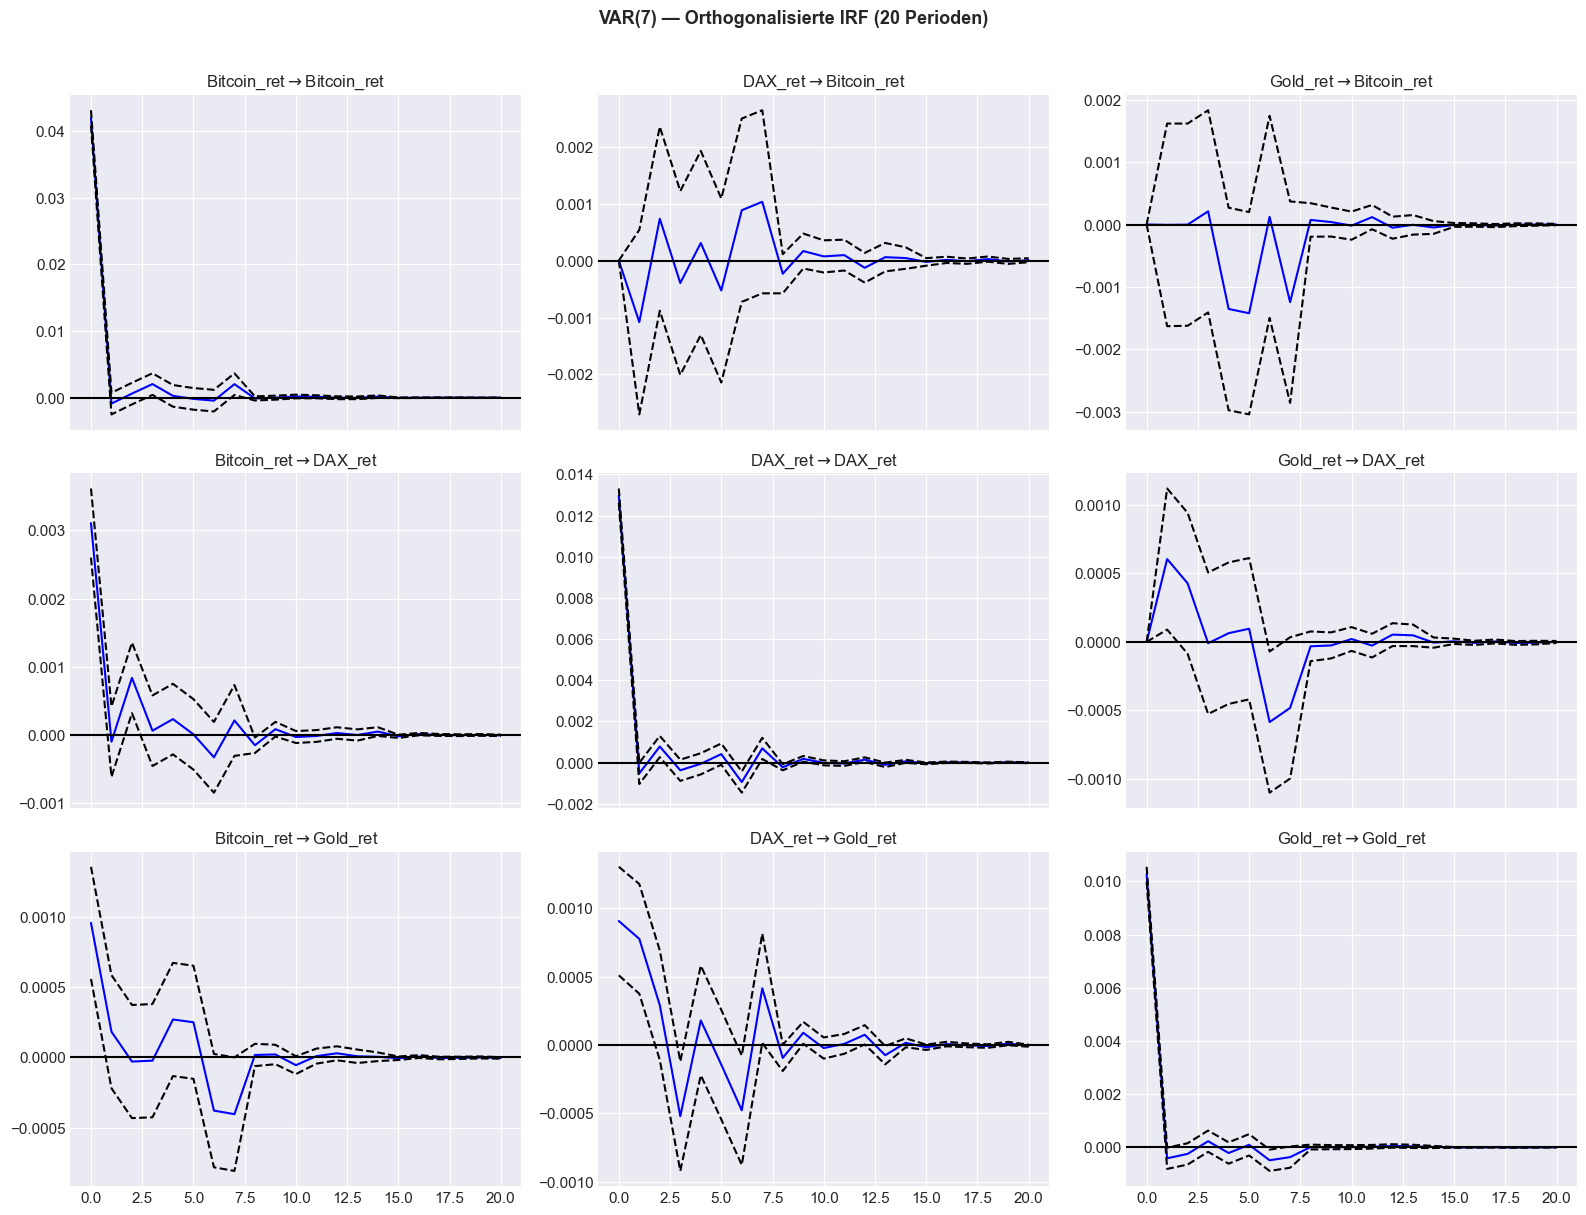

In [16]:
irf = var_final_fitted.irf(periods=20)
fig = irf.plot(orth=True, figsize=(16, 12))
fig.suptitle(f'VAR({best_lag}) — Orthogonalisierte IRF (20 Perioden)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/var_irf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Forecast Error Variance Decomposition (FEVD)

FEVD for Bitcoin_ret
      Bitcoin_ret   DAX_ret  Gold_ret
0        1.000000  0.000000  0.000000
1        0.999338  0.000662  0.000000
2        0.999031  0.000969  0.000000
3        0.998921  0.001054  0.000025
4        0.997836  0.001107  0.001057
5        0.996546  0.001261  0.002193
6        0.996098  0.001702  0.002200
7        0.994645  0.002296  0.003059
8        0.994612  0.002325  0.003062
9        0.994596  0.002341  0.003063
10       0.994593  0.002344  0.003063
11       0.994580  0.002349  0.003071
12       0.994569  0.002358  0.003072
13       0.994567  0.002360  0.003072
14       0.994565  0.002361  0.003074
15       0.994565  0.002362  0.003074
16       0.994565  0.002362  0.003074
17       0.994564  0.002362  0.003074
18       0.994564  0.002362  0.003074
19       0.994564  0.002362  0.003074

FEVD for DAX_ret
      Bitcoin_ret   DAX_ret  Gold_ret
0        0.054396  0.945604  0.000000
1        0.054251  0.943693  0.002056
2        0.057705  0.939238  0.003057
3        0.

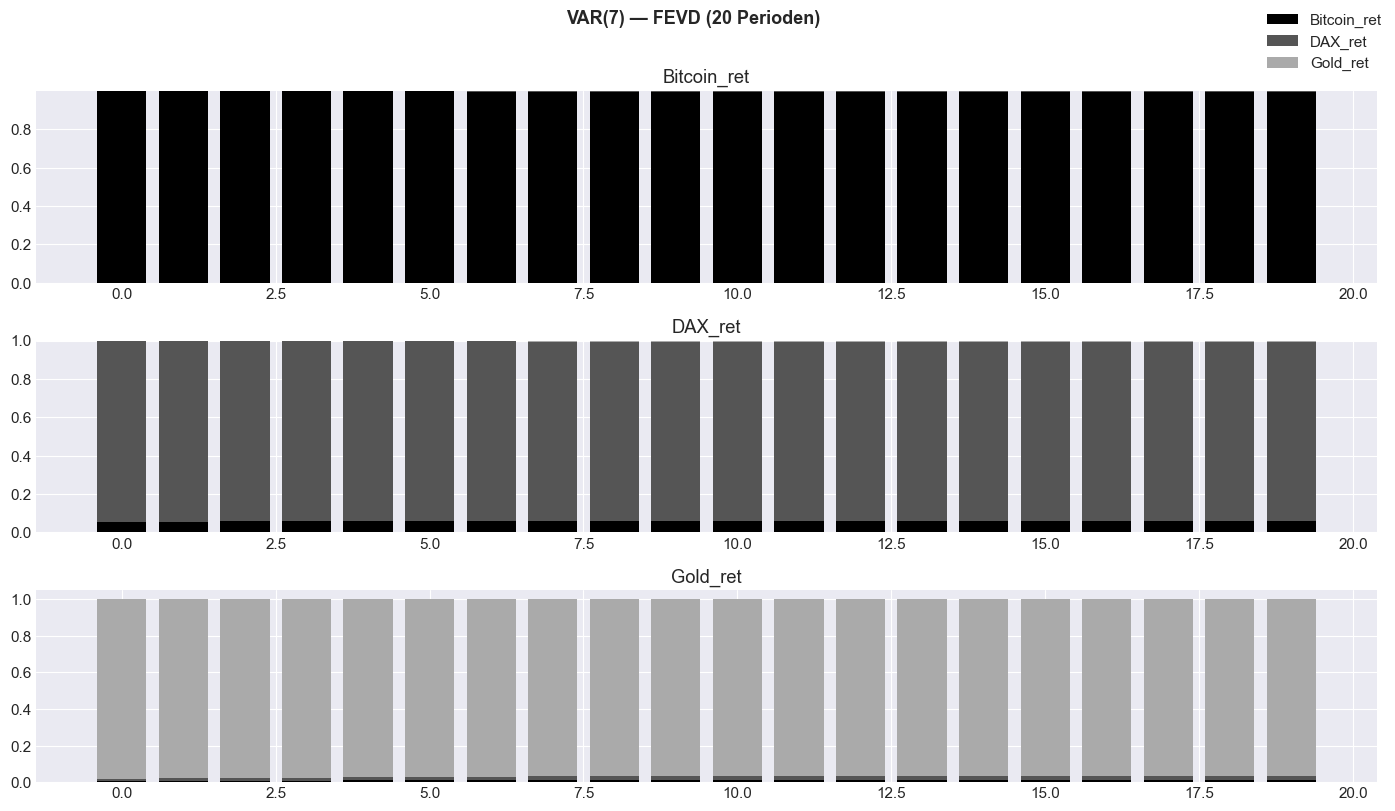

In [17]:
fevd = var_final_fitted.fevd(periods=20)
print(fevd.summary())

fig = fevd.plot(figsize=(14, 8))
plt.suptitle(f'VAR({best_lag}) — FEVD (20 Perioden)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/var_fevd.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Modellvergleich & Ergebniszusammenfassung

In [18]:
print(f'''
╔══════════════════════════════════════════════════════════════╗
║         ERGEBNISZUSAMMENFASSUNG — VAR-MODELL                ║
╠══════════════════════════════════════════════════════════════╣
║  Modell        : VAR({best_lag})                                      ║
║  Variablen     : Bitcoin · DAX · Gold (Log-Returns)         ║
║  Trainingsdaten: {train_ret.index[0].date()} → {train_ret.index[-1].date()}          ║
║  Testdaten     : {test_ret.index[0].date()} → {test_ret.index[-1].date()}             ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting (60-Tage Out-of-Sample):                       ║
║  Asset      MAE              RMSE           MAPE            ║
║  Bitcoin    {metrics["Bitcoin"]["MAE"]:>10,.2f}  {metrics["Bitcoin"]["RMSE"]:>14,.2f}  {metrics["Bitcoin"]["MAPE"]:>7.3f}%       ║
║  DAX        {metrics["DAX"]["MAE"]:>10,.4f}  {metrics["DAX"]["RMSE"]:>14,.4f}  {metrics["DAX"]["MAPE"]:>7.3f}%       ║
║  Gold       {metrics["Gold"]["MAE"]:>10,.2f}  {metrics["Gold"]["RMSE"]:>14,.2f}  {metrics["Gold"]["MAPE"]:>7.3f}%       ║
╚══════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════╗
║         ERGEBNISZUSAMMENFASSUNG — VAR-MODELL                ║
╠══════════════════════════════════════════════════════════════╣
║  Modell        : VAR(7)                                      ║
║  Variablen     : Bitcoin · DAX · Gold (Log-Returns)         ║
║  Trainingsdaten: 2016-01-05 → 2026-02-04          ║
║  Testdaten     : 2026-02-05 → 2026-05-01             ║
╠══════════════════════════════════════════════════════════════╣
║  Backtesting (60-Tage Out-of-Sample):                       ║
║  Asset      MAE              RMSE           MAPE            ║
║  Bitcoin      8,175.51        8,528.21   11.710%       ║
║  DAX            2.6796          3.1981    6.207%       ║
║  Gold           267.82          320.57    5.676%       ║
╚══════════════════════════════════════════════════════════════╝



In [19]:
import os

result_row = pd.DataFrame([{
    'Asset': 'VAR', 'Ticker': 'BTC+DAX+Gold',
    'Modell': f'VAR({best_lag})',
    'AIC': round(var_final_fitted.aic, 4),
    'BIC': round(var_final_fitted.bic, 4),
    'MAE_Bitcoin':  round(metrics['Bitcoin']['MAE'], 4),
    'MAE_DAX':      round(metrics['DAX']['MAE'], 4),
    'MAE_Gold':     round(metrics['Gold']['MAE'], 4),
    'MAPE_Bitcoin': round(metrics['Bitcoin']['MAPE'], 4),
    'MAPE_DAX':     round(metrics['DAX']['MAPE'], 4),
    'MAPE_Gold':    round(metrics['Gold']['MAPE'], 4),
}])

results_path = '../reports/results_var.csv'
os.makedirs('../reports', exist_ok=True)
result_row.to_csv(results_path, index=False)
print(f'Ergebnisse gespeichert: {results_path}')
print(result_row.to_string(index=False))

Ergebnisse gespeichert: ../reports/results_var.csv
Asset       Ticker Modell      AIC      BIC  MAE_Bitcoin  MAE_DAX  MAE_Gold  MAPE_Bitcoin  MAPE_DAX  MAPE_Gold
  VAR BTC+DAX+Gold VAR(7) -24.1648 -24.0153    8175.5083   2.6796  267.8208         11.71    6.2066     5.6758
